# **MURD-ViT**: Urban Retrofitting Detection with Vision Transformer
### *Where, When, and What* 

> **Authors of Notebook**: Raj Bhattarai (*iamrajbhattarai@vt.edu*), Fangzheng Lyu (*fangzheng@vt.edu*). GeoCompute Lab, Virginia Tech

> Bhattarai, R., Wang, S., Song, Y., Ma. X., Kang, Y., Michels, A, Lyu, F. MURD-ViT: Multimodal Urban Retrofitting Detection Using Street View Imagery and Demographic Data. In review at IEEE Journal of Selected Topics in Applied Earth Observations and Remote Sensing


## Overview
This notebook implements **MURD-ViT**, a multimodal deep learning pipeline designed to automate the detection of urban retrofitting. By integrating **temporal Google Street View (GSV)** imagery with **demographic data**, the model classifies urban changes into five distinct categories.


## Background: Why Urban Retrofitting?

With large-scale urban expansion reaching saturation levels in many developed countries, cities increasingly rely on urban retrofitting—localized improvements in pre-existing infrastructures that elevate functionality and sustainability. These small-scale urban retrofitting include physical renovations, land use adaptation, and greening initiatives and combines to improve a city's infrastructure, continuity, and habitability. Urban retrofitting has now become an established process to enhance sustainability and resilience of urban space by revitalizing existing urban spaces which are at risks of exclusion and inefficacy.

- Urban planners and policymakers can leverage MURD-ViT to analyze patterns of urban transformation over decades, thereby devising future planning, policies and strategies.
- Identification of urban retrofits can help monitor urban renewal projects and evaluate their progress over time.
- Moreover, detecting urban retrofitting hotspots and coldspots can aid in assessing whether such practices benefit vulnerable population.
- Environmental experts may employ the retrofitting model to estimate their sustainability and revitalization efforts, delivering quantitative insights of retrofitting on urban resilience.

### The Four Pillars of Retrofitting
1.  **Re-inhabitation:** Upgrading housing quality and socioeconomic diversity (Ma et al. 2025).
2.  **Re-building:** Optimizing existing structures for community density (Ma et al. 2025).
3.  **Re-transportation:** Building interconnected, sustainable mobility networks (Ma et al. 2025).
4.  **Re-capital:** Fostering sustainable local economic development (Ma et al. 2025).

<img alt="Urban Retrofitting Example" src="data/figures_low/UR.png" width="700" height="250" />

*Example: Allegheny Mall, Pittsburgh (Retrofitted into office/residential space) before/after 2016.*


## The Research Gap
Traditional detection methods (like satellite imagery) excel at macro-changes but struggle with "facade-level" micro-adjustments.

| Feature | Satellite Imagery | Proximate Sensing (GSV) |
| :--- | :--- | :--- |
| **Perspective** | Top-down (Exterior) | Street-level (Facade) |
| **Granularity** | Macro (Land use) | Micro (Retrofitting details) |
| **Socioeconomics** | Indirect / Estimated | Direct (Integrated via Demographics) |


## Study Area & Innovation
* **Scope:** Mecklenburg County (Charlotte), North Carolina (2013–2023).
* **Innovation:** **MURD-ViT** is the first computationally efficient model to automate retrofitting detection.
* **Impact:** Empowers urban planners with a scalable tool to monitor decades of transformation and support evidence-based decision-making.

## Why Mecklenburg County, NC?

- As a result of a 60.4% population growth between 2000 and 2020, Mecklenburg County experienced rapid urban growth, transit-induced redevelopment, and climate related challenges in and around the city, accelerating land conversion and infill.
- Transit investments such as light rail blue line network, have sparked capitalization and redevelopment effects on housing.
- Concurrently, the city faces environmental equity concerns and increased heat exposure patterns, emphasizing the need for retrofit actions that incorporate greening efforts and climate adaptation.
- Moreover, the Charlotte Future 2040 Comprehensive Plan supports infill, mixed-use and corridor retrofits.
- These factors combined make the detection of urban retrofitting growing significant in the city of Charlotte.


## Table of Contents
1. [Installation and Setup](#installation)
2. [Dataset](#dataset)
3. [Model Architecture](#architecture)
4. [Training and Validation Functions](#training)\
   [File Configuration and Set Hyperparameters](#config)
5. [Data Loading and Preprocessing](#data-loading)
6. [Model Training](#inference)
7. [Load GPU Trained Weights](#load-trained-weights)
8. [Evaluation and Prediction Results](#eval-results)
9. [Conclusion](#conclusion)
10. [Limitations and Future Direction](#limitations)
11. [User specifically interested in using data directly rather than from excel file annotations](#direct-use)

##  1. <a id="installation">Installation and Setup </a>

Install required Python packages for deep learning, computer vision, and geospatial analytics.

This entire workflow requires the core python dependencies: torch torchvision timm pandas geopandas numpy opencv-python scikit-learn matplotlib folium openpyxl.
The specific dependencies used are provided in requirements.txt.

For now, we can use `geoai` kernel of I-GUIDE Platform and install packages on top of that.

## Select `geoai` from kernel list on the top right.

In [1]:
# NOTE: When geoai Kernel is used.
%pip install --no-cache-dir timm==1.0.15 geopandas==1.0.1 opencv-python==4.11.0.86 openpyxl==3.1.5

# NOTE: When geoai-Python3 Kernel is used.
# %pip install --no-cache-dir openpyxl==3.1.5

Defaulting to user installation because normal site-packages is not writeable
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 65.2 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 323.6/323.6 kB 295.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.0/63.0 MB 256.1 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 250.9/250.9 kB 285.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 32.5/32.5 MB 190.5 MB/s eta 0:00:0000:0100:01
Note: you may need to restart the kernel to use updated packages.


Also, download trained model weights.

In [2]:
# Download Model weights from a google drive link.
!wget --no-check-certificate 'https://drive.usercontent.google.com/download?id=1WNYPvD1p7P-xT6GY4N2FuNbvjWA-BxmR&export=download&confirm=t' -O ./Model_Checkpoints/MURD-ViT_weights.pth

--2026-04-27 23:26:38--  https://drive.usercontent.google.com/download?id=1WNYPvD1p7P-xT6GY4N2FuNbvjWA-BxmR&export=download&confirm=t
Resolving drive.usercontent.google.com (drive.usercontent.google.com)... 142.251.34.225, 2607:f8b0:4009:800::2001
Connecting to drive.usercontent.google.com (drive.usercontent.google.com)|142.251.34.225|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1037264705 (989M) [application/octet-stream]
Saving to: ‘./Model_Checkpoints/MURD-ViT_weights.pth’

./Model_Checkpoints 100%[===================>] 989.21M  95.0MB/s    in 12s     

2026-04-27 23:26:51 (82.4 MB/s) - ‘./Model_Checkpoints/MURD-ViT_weights.pth’ saved [1037264705/1037264705]



Now let's import all dependencies

In [3]:
# Import all necessary libraries for data processing, model training, visualization, and geospatial operations.

import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler, Subset
import torchvision.transforms as T
import timm
import pandas as pd
import geopandas as gpd
import numpy as np
import cv2
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.cluster import KMeans
import folium
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
import gc
from datetime import datetime
import logging
from sklearn.utils.class_weight import compute_class_weight
from PIL import Image

### Device Configuration

Set the computation device (CUDA GPU or CPU) for PyTorch operations.


In [4]:
# set the device for torch backend
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cpu')

## 2.<a id="dataset">Dataset</a>

The study focuses on **Mecklenburg County, North Carolina (Charlotte)**, leveraging a comprehensive spatiotemporal dataset that merges visual and demographic layers from **2013 to 2023**.


### Data Sources
* **Visual Data:** Temporal Google Street View (GSV) image pairs capturing micro-scale urban changes.
* **Demographic Data:** Yearly population counts and density metrics at the **Census Block Group** level, sourced from the [U.S. Census Bureau Data Portal](https://data.census.gov/).

<img alt="Urban Retrofitting across Charlotte, NC." src="data/figures_low/UR_SVI.png" width="1100" height="650" />

*Figure: Distribution of retrofits across Census Block Groups and sample temporal image pairs.*

### Data Collection & Structure
To capture high-resolution urban evolution, we implemented a hierarchical sampling strategy:
1.  **Sampling:** 10 random locations selected within each of the **555 census block groups**.
2.  **Retrieval:** Historical images were pulled for four cardinal directions using **GSV Panorama IDs** and the **Street View Static API**.
3.  **Temporal Pairing:** Every historical image was cross-paired with subsequent images at the same location to create "Before/After" sequences.

#### Dataset Composition (7,376 Total Pairs)
| Category | Image Pairs | Description |
| :--- | :--- | :--- |
| **No Change** | 5,580 | Baseline/Static urban environments |
| **Re-building** | 962 | Structural optimizations and densification |
| **Re-inhabitation** | 528 | Housing quality and socioeconomic upgrades |
| **Re-transportation** | 225 | Sustainable mobility and network changes |
| **Re-capital** | 81 | Economic and commercial development |

\
<img alt="Street View Image Locations, NC." src="data/figures_low/study_area.png" width="800" height="650" />

 An **Excel sheet** consisting of `Census Blockgroups`, `Latitude`, `Longitude`, `Direction`, `Start Date` (Date before Retrofitting), `End Date` (Date after Retrofitting), `Retrofitting Type`, `Population Density Change` and `Change Percentage` is created acting as a guide to load image data and values for demographic components.

### 2.1. Custom Dataset Class

Define the `UrbanRetrofittingDataset` class that loads temporal image pairs (before/after) along with demographic features and labels. The dataset handles coordinate precision, image loading, and label encoding.


In [5]:
# Structure images, demographic data and labels.

class UrbanRetrofittingDataset(Dataset):
    def __init__(self, excel_file, image_dir, transform=None):
        """
        Args:
            excel_file (str): Path to the Excel file with annotations.
            image_dir (str): Directory with all the images.
            transform (callable, optional): Optional transform to be applied on an image pair.

        Returns:
            (start_image, end_image, socio_economic_data, label): Tuple containing the start and end images, socio-economic data, and the label for each sample.
        """
        
        self.data = pd.read_excel(excel_file, dtype={"Latitude": str, "Longitude": str})
        # maintains precision. Do not change this two step conversion.
        self.data = self.data.astype({"Latitude": np.longdouble, "Longitude": np.longdouble})
        self.image_dir = image_dir
        self.transform = transform
        self.label_encoder = LabelEncoder()
        self.data['Change'] = self.label_encoder.fit_transform(self.data['Change'])  # Encode labels

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        census_block = str(row['ID'])
        lat, lon, direction = row['Latitude'], row['Longitude'], row['Heading']
        start_date, end_date = row['Start'], row['End']
        pop_density_change = row['PopDen_Diff']
        change_percentage = row['PopDen_Diff_Percentage']
        label = row['Change']

        # Load image pair Do not use f{} formatting to add longdouble number
        start_image_path = os.path.join(self.image_dir, census_block,  str(lat)+"_"+str(lon)+"_"+str(direction), f"{pd.to_datetime(start_date).strftime('%b %Y')}.png")
        end_image_path = os.path.join(self.image_dir, census_block, str(lat)+"_"+str(lon)+"_"+str(direction), f"{pd.to_datetime(end_date).strftime('%b %Y')}.png")
        start_image = Image.open(start_image_path).convert('RGB')
        end_image = Image.open(end_image_path).convert('RGB')

        if self.transform:
            start_image = self.transform(start_image)
            end_image = self.transform(end_image)

        # demographic data
        socio_economic_data = torch.tensor([pop_density_change, change_percentage], dtype=torch.float32)

        return start_image, end_image, socio_economic_data, label

<!-- ## 3. <a id="architecture">Model Architecture</a>

Our proposed MURD-ViT, first of its kind deep learning model for urban retrofitting detection, uses a Vision Transformer as its backbone. Vision Transformers have been shown to outperform state-of-the art convolutional architectures such as ResNet on various computer vision tasks by its ability to model global spatial dependencies, particularly when pre-trained on large-scale datasets (14-300 million images) and fine-tuned to specialized tasks with limited data samples. ViT is adapted from Transformer architecture primarily introduced for Natural Language Processing (NLP) by retaining only the encoder block. The input images are divided into fixed size patches, flattened and treated as tokens with added positional encodings, in analogy with words in NLP tasks. The figure below represents the overall architecture of the proposed MURD-ViT model. ViT backbone provides richer low dimensional embeddings of street view images. Demographic MLP undertakes population data and linearly transforms into richer representations. Feature Concatenation integrates the output features from the ViT backbone, and Demographic MLP, producing combined features which are passed to the new Classifier Head for further processing. The Classifier Head then performs linear transformations, applies activation function and dropout operation, and finally maps combined features to retrofit categories.

<img alt= "MURD-ViT Architecture" src="data/figures_low/architecture.png" width="1000" height="700" />

Now, let's implement the `ViTWithSocioEconomic` model that combines:
- Pretrained ViT for extracting image features from start and end images
- Difference features (end - start) to capture temporal changes
- Demographic data embedding
- Classification head for 5-class urban retrofitting detection -->

## 3. <a id="architecture">Model Architecture</a>

The **MURD-ViT** (Multimodal Urban Retrofitting Detection - Vision Transformer) is a first-of-its-kind deep learning framework tailored for urban change detection. It leverages the **Vision Transformer (ViT)** backbone, which excels at capturing global spatial dependencies by treating image patches as tokens—similar to words in Natural Language Processing (NLP).



### Core Components

* **ViT Backbone:** Processes "Before" and "After" street view images to extract high-dimensional spatial embeddings. By using a transformer-based encoder, the model identifies subtle micro-scale facade changes that traditional CNNs might miss.
* **Demographic MLP:** A Multi-Layer Perceptron that ingests population counts and density metrics, transforming raw demographic data into rich representational vectors.
* **Temporal Feature Fusion:** Instead of analyzing images in isolation, the model calculates **Difference Features ($End - Start$)** to explicitly capture the signal of change over time.
* **Feature Concatenation:** Integrates the visual embeddings (from both time steps), the temporal difference, and the demographic embeddings into a single unified feature vector.
* **Custom Classifier Head:** A final sequence of linear transformations, activation functions, and dropout layers that maps the fused features to the **five urban retrofitting categories**.


### Technical Workflow

<img alt="MURD-ViT Architecture" src="data/figures_low/architecture.png" width="1000" height="700" />

1.  **Patch Embedding:** Input images are divided into fixed-size patches and flattened.
2.  **Positional Encoding:** Added to maintain spatial context.
3.  **Multimodal Integration:**
    * **Visual:** Pre-trained ViT weights are fine-tuned for street-level features.
    * **Socio-Economic:** Demographic data provides the "neighborhood context" for the visual changes.
4.  **Classification:** The head outputs probabilities across: *No Change, Re-building, Re-inhabitation, Re-transportation,* and *Re-capital*.


### Implementation: `ViTWithSocioEconomic`
We will now define the model class which orchestrates the pretrained ViT, the socio-economic embedding layers, and the temporal difference logic.


In [7]:
# Model architecture

class ViTWithSocioEconomic(nn.Module):
    def __init__(self, num_numeric_features, num_classes):
        super(ViTWithSocioEconomic, self).__init__()
        # Pretrained ViT model from timm library without classification head to get image embeddings.
        self.vit = timm.create_model('vit_base_patch16_224', pretrained=True, num_classes=0)
        img_embedding_dim = self.vit.num_features

        # Numeric features embedding
        self.numeric_embed = nn.Sequential(
            nn.Linear(num_numeric_features, 32),
            nn.ReLU(),
            nn.Linear(32, 32)
        )

        # Classification head
        self.classifier = nn.Sequential(
            nn.Linear(3 * img_embedding_dim + 32, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    # Forward pass
    def forward(self, start_image, end_image, numeric_feats):
        start_feat = self.vit(start_image)
        end_feat = self.vit(end_image)
        diff_feat = end_feat - start_feat
        numeric_feat = self.numeric_embed(numeric_feats)
        combined = torch.cat([start_feat, end_feat, diff_feat, numeric_feat], dim=1)
        return self.classifier(combined)

## 4. <a id="training">Training and Validation Functions</a>

### 4.1 Training Function

Implement the training loop with per-class accuracy and loss tracking. This function processes batches, computes gradients, and updates model parameters while monitoring performance metrics for each class.


In [8]:
# Training function with per-class accuracy and loss tracking

def train_epoch(model, loader, criterion, optimizer, device, num_classes):
    model.train()
    total_samples = 0
    running_loss = 0.0
    correct_total = 0
    
    class_correct = [0] * num_classes
    class_total = [0] * num_classes
    class_losses = [0.0] * num_classes
    
    for start_imgs, end_imgs, socio_econ, labels in loader:
        start_imgs, end_imgs = start_imgs.to(device), end_imgs.to(device)
        socio_econ, labels = socio_econ.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(start_imgs, end_imgs, socio_econ)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        batch_size = labels.size(0)
        running_loss += loss.item() * batch_size
        total_samples += batch_size

        preds = outputs.argmax(dim=1)
        correct_total += (preds == labels).sum().item()

        for cls in range(num_classes):
            cls_mask = labels == cls
            if cls_mask.sum() > 0:
                cls_outputs = outputs[cls_mask]
                cls_labels = labels[cls_mask]
                class_losses[cls] += criterion(cls_outputs, cls_labels).item() * cls_mask.sum().item()
                class_correct[cls] += (cls_outputs.argmax(dim=1) == cls_labels).sum().item()
                class_total[cls] += cls_mask.sum().item()

    epoch_loss = running_loss / total_samples
    overall_acc = 100 * correct_total / total_samples

    class_acc = [100 * class_correct[i] / class_total[i] if class_total[i] else 0 for i in range(num_classes)]
    class_avg_loss = [class_losses[i] / class_total[i] if class_total[i] else 0 for i in range(num_classes)]

    return epoch_loss, overall_acc, class_acc, class_avg_loss

### 4.2 Validation Function

Implement validation with top-2 accuracy metric. This function evaluates the model on validation data, computes per-class metrics, and stores predictions for later analysis. Top-2 accuracy considers a prediction correct if the true label is among the top 2 predicted classes.

The reason we implemented top2 predictions for validation is due to the nature of Urban Retrofitting; it itself is very rare thus, heavily dominated by No Change category rather than actual retrofit categories. In such scenario, it is standard practice to implement top2 predictions.


In [9]:
# Validation function with top-2 accuracy and per-class metrics

def validate_epoch(model, loader, criterion, device, num_classes):
    model.eval()
    total_samples = 0
    running_loss = 0.0
    correct_total = 0

    class_correct = [0] * num_classes
    class_total = [0] * num_classes
    class_losses = [0.0] * num_classes
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for start_imgs, end_imgs, socio_econ, labels in loader:
            start_imgs, end_imgs = start_imgs.to(device), end_imgs.to(device)
            socio_econ, labels = socio_econ.to(device), labels.to(device)

            outputs = model(start_imgs, end_imgs, socio_econ)
            loss = criterion(outputs, labels)

            batch_size = labels.size(0)
            running_loss += loss.item() * batch_size
            total_samples += batch_size

            _, preds_top2 = outputs.topk(2, dim=1)
            correct_top2 = preds_top2.eq(labels.unsqueeze(1)).any(dim=1)
            stored_pred_batch = torch.where(correct_top2, labels, preds_top2[:, 0])

            all_preds.extend(stored_pred_batch.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            correct_total += correct_top2.sum().item()

            for cls in range(num_classes):
                cls_mask = labels == cls
                if cls_mask.sum() > 0:
                    cls_outputs = outputs[cls_mask]
                    cls_labels = labels[cls_mask]
                    class_losses[cls] += criterion(cls_outputs, cls_labels).item() * cls_mask.sum().item()
                    class_correct[cls] += correct_top2[cls_mask].sum().item()
                    class_total[cls] += cls_mask.sum().item()


    epoch_loss = running_loss / total_samples
    overall_acc = 100 * correct_total / total_samples

    class_acc = [100 * class_correct[i] / class_total[i] if class_total[i] else 0 for i in range(num_classes)]
    class_avg_loss = [class_losses[i] / class_total[i] if class_total[i] else 0 for i in range(num_classes)]

    return epoch_loss, overall_acc, class_acc, class_avg_loss, all_preds, all_labels

## <a id="config">Configuration and Hyperparameters</a>

Set up directories for checkpoints and logs, define model name, and configure hyperparameters including batch size, learning rate, number of epochs, and dataset paths.


In [10]:
# create a directory for saving and loading checkpoints.
RUN_SAMPLE = True # Set to False to run with full data.

# Hyperparameters
LEARNING_RATE = 0.0001
WEIGHT_DECAY_RATE = 0.00001
NUM_CLASSES = 5  # Five aspects of urban retrofitting

if RUN_SAMPLE:
    BATCH_SIZE = 8
    NUM_EPOCHS = 1

    # Dataset and DataLoader
    excel_File = "./data/Sample_data/labels.xlsx"
    image_dir = "./data/Sample_data/Streetview_data"

    # Number of clusters to form for Spatial Stratified Sampling.
    NO_OF_CLUSTERS = 4

    # Save model weights so, directory for storing checkpoints.
    checkpoint_dir = "Model_Checkpoints/Sample_Checkpoints"
    
else:
    # Following parameters were while training with full dataset on HPRC server.
    #  NOTE: Please see 7. Load GPU Trained Weights section for environment and resources details.
    BATCH_SIZE = 256
    NUM_EPOCHS = 30 

    # Dataset and DataLoader
    excel_File = "./data/Full_data/labels.xlsx"
    image_dir = "./data/Full_data/Streetview_data"

    # Number of clusters to form for Spatial Stratified Sampling.
    NO_OF_CLUSTERS = 20

    # Save model weights so, directory for storing checkpoints.
    checkpoint_dir = "Model_Checkpoints"

# Configure directories for checkpoint and logs
os.makedirs(checkpoint_dir, exist_ok=True)

MODEL_NAME = "MURD-ViT"
CHECKPOINT_PATH = f"{checkpoint_dir}/{MODEL_NAME}_epoch_1.pth"

# directory for storing logs
logs_dir = "logs"
os.makedirs(logs_dir, exist_ok=True)

LOG_FILE = f"{logs_dir}/{MODEL_NAME}.txt"

### Logging Configuration

Configure logging to write training progress to both a file and console for monitoring and debugging purposes.


In [11]:
# Configure logging to file and console

logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s',
    handlers=[
        # Append mode
        logging.FileHandler(LOG_FILE, mode='a'),
        # Also print to console
        logging.StreamHandler()
    ]
)
logger = logging.getLogger(__name__)

## 5. <a id="data-loading">Data Loading and Preprocessing</a>

### 5.1 Data Transformations and Spatial Stratified Split

Load the dataset with appropriate transformations:
- **Training transforms**: Include data augmentation (random flips, rotations, color jitter) to improve generalization
- **Validation transforms**: Only resize and normalize (no augmentation)

Implement spatial stratified sampling to ensure:
- K-Means Clustering to create 20 clusters in full dataset.
- Geographic diversity: Samples are split across spatial clusters
- Class balance: Each cluster maintains proportional class distribution as well as 80-20 training test split.
- Reproducibility: Fixed random seed for consistent splits

The following figures show spatial stratified sampling implemented in our full dataset.

<img alt= "Spatial Stratified Sampling" src="data/figures_low/stratified_spatial_sampling.png" width="1000" height="650" />



In [12]:
# Data Loading

# Set random seed for reproducibility
np.random.seed(42)
torch.manual_seed(42)

# Data transformations

train_transform = T.Compose([
    T.Resize((224, 224)),
    T.RandomHorizontalFlip(),
    T.RandomRotation(10),
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225])
])

val_transform = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Spatial stratified sampling split function 

def spatial_stratified_split(dataset, val_ratio=0.2, n_clusters=10):
    """
    Perform spatial stratified sampling split and return PyTorch-compatible UrbanRetrofittingDataset subsets.
    NOTE: n_clusters = 4 included at least 1 sample per class in each cluster. 
    Args:
        df (pd.DataFrame): Raw dataframe loaded from Excel.
        image_dir (str): Path to the image directory.
        transform (callable): Torchvision transform for images.
        val_ratio (float): Ratio for validation split.
        n_clusters (int): Number of spatial clusters.

    Returns:
        train_dataset (Subset), val_dataset (Subset), label_encoder
    """
    df = dataset.data.copy()
    
    # Ensure correct types
    df = df.dropna(subset=['Latitude', 'Longitude'])

    # Spatial clustering
    coords = df[['Latitude', 'Longitude']].values
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    df['Cluster'] = kmeans.fit_predict(coords)

    # Stratified sampling within each spatial cluster
    train_indices, val_indices = [], []

    for cluster in df['Cluster'].unique():
        cluster_df = df[df['Cluster'] == cluster]
        for label in cluster_df['Change'].unique():
            label_df = cluster_df[cluster_df['Change'] == label]
            n_val = max(1, int(len(label_df) * val_ratio))
            val_sample = label_df.sample(n=n_val, random_state=42)
            train_sample = label_df.drop(val_sample.index)
            train_indices.extend(train_sample.index)
            val_indices.extend(val_sample.index)

    # Reset index to use Subset
    df.reset_index(drop=True, inplace=True)

    dataset.data = df

    # Convert to GeoDataFrame
    gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df['Longitude'], df['Latitude']), crs='EPSG:4326')

    return train_indices, val_indices, gdf

logger.info("Data Loading Initiated!")
# initializing dataset twice to use multiple transforms for training and validation.
train_dataset = UrbanRetrofittingDataset(excel_File, image_dir, train_transform)
val_dataset = UrbanRetrofittingDataset(excel_File, image_dir, val_transform)

# use any one to get train and val indices.
train_indices, val_indices, clusters_gdf = spatial_stratified_split(dataset=train_dataset, val_ratio=0.2, n_clusters=NO_OF_CLUSTERS)
_,_,_ = spatial_stratified_split(dataset=val_dataset, val_ratio=0.2, n_clusters=NO_OF_CLUSTERS)

train_dataset = Subset(train_dataset, train_indices)
val_dataset = Subset(val_dataset, val_indices)
logger.info("Split data into training and validation.")


2026-04-27 23:28:45,512 - INFO - Data Loading Initiated!
/cvmfs/iguide.purdue.edu/software/conda/geoai/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/cvmfs/iguide.purdue.edu/software/conda/geoai/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
2026-04-27 23:28:46,028 - INFO - Split data into training and validation.


### 5.2 Dataset Distribution Logging

Log the distribution of classes in training and validation sets to verify balanced splits and understand data composition.


In [13]:
# Log cluster distribution

all_labels = train_dataset.dataset.data['Change']

def log_distribution(all_labels, dataset, name):
    label_counts = Counter([all_labels[i] for i in dataset.indices])
    label_encoder = dataset.dataset.label_encoder
    logger.info(f"{name} distribution:")
    for label_idx in sorted(label_counts):
        logger.info(f"\t{label_encoder.classes_[label_idx]}: {label_counts[label_idx]}")

log_distribution(all_labels, train_dataset, "Train")
log_distribution(all_labels, val_dataset, "Validation")

2026-04-27 23:28:49,507 - INFO - Train distribution:
2026-04-27 23:28:49,508 - INFO - 	No Change: 19
2026-04-27 23:28:49,509 - INFO - 	re-building: 17
2026-04-27 23:28:49,509 - INFO - 	re-capital: 3
2026-04-27 23:28:49,510 - INFO - 	re-inhabitation: 5
2026-04-27 23:28:49,510 - INFO - 	re-transportation: 8
2026-04-27 23:28:49,510 - INFO - Validation distribution:
2026-04-27 23:28:49,511 - INFO - 	No Change: 4
2026-04-27 23:28:49,511 - INFO - 	re-building: 3
2026-04-27 23:28:49,511 - INFO - 	re-capital: 1
2026-04-27 23:28:49,512 - INFO - 	re-inhabitation: 2
2026-04-27 23:28:49,512 - INFO - 	re-transportation: 2


### 5.3 Training Set Cluster Analysis

Display the distribution of samples across spatial clusters and classes in the training set. This helps verify that the spatial stratified split maintains class representation in each cluster.


In [14]:
# Summary of clusters and class distribution for training set

train_df = train_dataset.dataset.data.loc[train_indices]
counts = train_df.groupby(['Cluster', 'Change']).size().unstack(fill_value=0)
logger.info("Training Sample counts per class in each cluster:")
logger.info(f"\n{counts}")

2026-04-27 23:28:52,189 - INFO - Training Sample counts per class in each cluster:
2026-04-27 23:28:52,196 - INFO - 
Change    0   1  2  3  4
Cluster                 
0        12   7  3  0  8
1         0   0  0  3  0
2         7  10  0  0  0
3         0   0  0  2  0


### 5.4 Validation Set Cluster Analysis

Display the distribution of samples across spatial clusters and classes in the validation set to ensure proper validation coverage.


In [15]:
# Summary of clusters and class distribution for validation set

val_df = val_dataset.dataset.data.loc[val_indices]
counts = val_df.groupby(['Cluster', 'Change']).size().unstack(fill_value=0)
logger.info("Validation Sample counts per class in each cluster:")
logger.info(f"\n{counts}")

2026-04-27 23:28:53,943 - INFO - Validation Sample counts per class in each cluster:
2026-04-27 23:28:53,945 - INFO - 
Change   0  1  2  3  4
Cluster               
0        3  1  1  0  2
1        0  0  0  1  0
2        1  2  0  0  0
3        0  0  0  1  0


### 5.5 Spatial Stratified Sampling Locations Data Visualization

Uncomment and run the following cells only **if you run with full dataset.**


In [16]:
# import matplotlib.cm as cm
# import matplotlib.colors as mcolors

# # Prepare colors for classes
# classes = train_dataset.dataset.label_encoder.classes_
# num_classes = len(classes)
# # colormap = cm.get_cmap('tab10', num_classes)
# # class_colors = {classes[i]: mcolors.rgb2hex(colormap(i)) for i in range(num_classes)}
# class_colors = {
#     'No Change': "#9caab6",
#     're-building': "#8243ab",
#     're-capital': '#2e8453',
#     're-inhabitation': '#08478c',
#     're-transportation': "#b82200"
# }

# # Get cluster polygons (convex hull)
# cluster_polys = clusters_gdf[['Cluster', 'geometry']].dissolve(by='Cluster', as_index=False, aggfunc='first')
# cluster_polys['geometry'] = cluster_polys.geometry.convex_hull
# cluster_polys = gpd.GeoDataFrame(cluster_polys, geometry="geometry", crs='EPSG:4326')
# cluster_polys.rename(columns={0: 'geometry'}, inplace=True)

# # Function to build dynamic map to view clusters and locations using folium.
# def create_folium_cluster_map(data_gdf, class_colors, title):
#     m = folium.Map(location=[data_gdf['Latitude'].mean(), data_gdf['Longitude'].mean()], tiles="Cartodb Positron", zoom_start=11, zoom_control=False)
    
#     # Plot clusters (polygons)
#     for _, row in cluster_polys.iterrows():
#         folium.GeoJson(
#             row['geometry'],
#             style_function=lambda feature, clr=row['Cluster']: {
#                 'fillColor': "#e7e7e7",
#                 'color': 'black',
#                 'weight': 1,
#                 'fillOpacity': 0.8
#             },
#             tooltip=f"Cluster {row['Cluster']}"
#         ).add_to(m)

#     # Add class samples as points
#     for _, row in data_gdf.iterrows():
#         cls = row['Change']
#         color = class_colors[classes[cls]]
#         popup = f"Class: {cls}<br>Cluster: {row['Cluster']}"
#         folium.CircleMarker(
#             location=[row['Latitude'], row['Longitude']],
#             radius=2.5,
#             color="white",      # Outline color
#             weight=0.5,           # Outline thickness
#             fill=True,
#             fill_color=color,
#             fill_opacity=1,
#             popup=popup
#         ).add_to(m)

#     # Add legend
#     legend_html = "<div style='position: fixed; top: 20px; right: 20px; z-index: 9999; background-color: white; padding: 10px; border: 1px solid #ccc;'>"
#     legend_html += "<b>Retrofit Category</b><br>"
#     for cls, color in class_colors.items():
#         legend_html += f"<i style='background:{color}; width:10px;height:10px;display:inline-block;border-radius:50%;'></i> {cls}<br>"
#     legend_html += "</div>"
#     m.get_root().html.add_child(folium.Element(legend_html))
#     # # Add the Fullscreen plugin to the map
#     # Fullscreen().add_to(m)
#     return m

# # Generate and save maps
# train_map = create_folium_cluster_map(train_df, class_colors, "Training Data Map")
# val_map = create_folium_cluster_map(val_df, class_colors, "Validation Data Map")

In [17]:
# # visualize training set map.
# train_map

In [18]:
# # visualize validation set map. 
# val_map

### Training Set DataFrame Display

Display the training dataset DataFrame for inspection of data structure and content.


In [19]:
# display training set dataframe.
train_df

,ID,Latitude,Longitude,Heading,Start,End,Change,PopDen_Diff,PopDen_Diff_Percentage,Cluster
0,371190001001,35.219878,-80.852954,0,2014-05-01,2015-03-01,0,195.615409,11.800487,2
6,371190001001,35.221657,-80.852021,0,2014-05-01,2015-07-01,0,195.615409,11.800487,2
7,371190001001,35.221657,-80.852021,90,2017-04-01,2018-04-01,0,615.079378,28.424977,2
8,371190001001,35.221657,-80.852021,180,2014-05-01,2015-07-01,0,195.615409,11.800487,2
11,371190001001,35.221657,-80.852021,270,2016-03-01,2017-04-01,0,-239.981790,-9.983221,2
16,371190001001,35.221795,-80.850877,0,2021-06-01,2022-09-01,0,1353.711448,13.783689,2
19,371190001001,35.221795,-80.850877,270,2016-02-01,2016-12-01,0,0.000000,0.000000,2
1,371190001001,35.219878,-80.852954,0,2015-03-01,2016-03-01,1,550.546459,29.706202,2
2,371190001001,35.219878,-80.852954,0,2019-02-01,2021-05-01,1,6364.567011,184.130918,2
3,371190001001,35.219878,-80.852954,180,2019-02-01,2021-05-01,1,6364.567011,184.130918,2


### Validation Set DataFrame Display

Display the validation dataset DataFrame for inspection of data structure and content.


In [20]:
# display validation set dataframe.
val_df

,ID,Latitude,Longitude,Heading,Start,End,Change,PopDen_Diff,PopDen_Diff_Percentage,Cluster
4,371190001001,35.219878,-80.852954,270,2015-03-01,2016-03-01,0,550.546459,29.706202,2
17,371190001001,35.221795,-80.850877,90,2018-03-01,2019-03-01,1,677.595642,24.383164,2
15,371190001001,35.221795,-80.850877,0,2019-03-01,2021-06-01,1,6364.567011,184.130918,2
43,371190001002,35.230017,-80.846622,270,2018-03-01,2019-03-01,0,139.298685,1.207729,0
48,371190001002,35.231122,-80.847268,270,2016-04-01,2017-04-01,0,-161.586475,-1.469098,0
20,371190001001,35.229260,-80.846420,0,2014-05-01,2015-03-01,0,195.615409,11.800487,0
22,371190001001,35.229260,-80.846420,0,2018-03-01,2019-03-01,2,677.595642,24.383164,0
31,371190001002,35.229649,-80.847122,90,2014-05-01,2015-03-01,1,1036.382218,12.054439,0
53,371190001002,35.231590,-80.847864,270,2018-03-01,2020-03-01,4,373.320476,3.236715,0
37,371190001002,35.230017,-80.846622,0,2019-03-01,2020-03-01,4,234.021791,2.004773,0


### 5.6 Class Weights for Sampling

Compute class weights for the weighted random sampler to address class imbalance during training. These weights ensure that underrepresented classes are sampled more frequently during training.


In [21]:
# Extract labels from training dataset
all_labels = train_dataset.dataset.data['Change'] 
train_labels = [all_labels[i] for i in train_dataset.indices]
num_classes = len(set(train_labels))

# Compute class sample weights
# class_counts = np.array([train_labels.count(i) for i in range(num_classes)])
# class_weights_sampler = 1. / class_counts

# Class sample weights calculated manually to avoid extreme weights for very rare classes.
class_weights_sampler = np.array([0.0036, 0.0034, 0.0150, 0.0050, 0.0060])
sample_weights = np.array([class_weights_sampler[label] for label in train_labels])

### 5.7 Weighted Random Sampler

Create a weighted random sampler that uses the computed class weights to balance the training data during batch creation. This helps the model learn from all classes more evenly.


In [22]:
# Weighted sampler for drawing training samples.
sampler = WeightedRandomSampler(weights=sample_weights,
                                 num_samples=len(sample_weights),
                                 replacement=True)

### 5.8 Class Weights for Loss Function

Compute class weights for the loss function to penalize misclassifications of rare classes more heavily. This helps the model focus on learning underrepresented classes during optimization.


In [23]:

# Compute class weights for loss function.
# class_weights = compute_class_weight(
#     class_weight='balanced',
#     classes=np.unique(labels),
#     y=labels
# )

# Manually experimented class weights to avoid extreme weights for very rare classes.
class_weights = np.array([1.66, 7.22, 5.56, 9.22, 9.34])

weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)
logger.info("Class weights used for loss function:")
for label, weight in zip(train_dataset.dataset.label_encoder.classes_, class_weights):
    logger.info(f"\tClass {label}: Weight={weight:.4f}")

2026-04-27 23:29:00,197 - INFO - Class weights used for loss function:
2026-04-27 23:29:00,198 - INFO - 	Class No Change: Weight=1.6600
2026-04-27 23:29:00,199 - INFO - 	Class re-building: Weight=7.2200
2026-04-27 23:29:00,199 - INFO - 	Class re-capital: Weight=5.5600
2026-04-27 23:29:00,200 - INFO - 	Class re-inhabitation: Weight=9.2200
2026-04-27 23:29:00,200 - INFO - 	Class re-transportation: Weight=9.3400


### 5.9 Data Loading Workers Configuration (Used later when GPU is available)

Determine the optimal number of worker processes for parallel data loading. Using multiple workers speeds up data preprocessing and loading during training.


In [24]:
# to enable faster data loading using multiple workers for data loading.
import multiprocessing
num_workers = multiprocessing.cpu_count() // 2
num_workers

4

### 5.10 Data Loader Initialization

Create PyTorch DataLoaders for training and validation sets with:
- Batch size configuration
- Weighted sampling for training (to handle class imbalance)
- Multiple workers for parallel data loading
- Pinned memory for faster GPU transfer


In [25]:
# Data Loaders.
if device.type == 'cuda':
    logger.info(f"Using Cuda. Batch Size: {BATCH_SIZE}, Workers: {num_workers}, pin_memory: True, LR: {LEARNING_RATE}, Wt. Decay: {WEIGHT_DECAY_RATE}")# this will be a lazy loader. Just initialization happens here. Real work happens inside for loop of data loader.
    
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler, num_workers=num_workers, pin_memory=True)
    logger.info("Training Loader is now ready!")
    
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=num_workers, pin_memory=True)
    logger.info("Validation Loader is now ready!")
else:
    logger.info(f"Using CPU. Batch Size: {BATCH_SIZE}, LR: {LEARNING_RATE}, Wt. Decay: {WEIGHT_DECAY_RATE}")# this will be a lazy loader. Just initialization happens here. Real work happens inside for loop of data loader.
    
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler)
    logger.info("Training Loader is now ready!")
    
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
    logger.info("Validation Loader is now ready!")

2026-04-27 23:29:02,582 - INFO - Using CPU. Batch Size: 8, LR: 0.0001, Wt. Decay: 1e-05
2026-04-27 23:29:02,584 - INFO - Training Loader is now ready!
2026-04-27 23:29:02,584 - INFO - Validation Loader is now ready!


## 6. <a id="inference">Model Training</a>

Initialize the model, loss function, and optimizer. The training loop:
- Trains the model for specified number of epochs
- Validates after each epoch.
- Logs per-class and overall metrics
- Saves checkpoints and supports resuming from checkpoints if training is interrupted.

For short runtime only one epoch was set in [File Configuration and Set Hyperparameters](#config)

and this takes approximately **2.5 minutes** to run in I-GUIDE platform using CPU.


In [26]:
# Inference

# Model, Loss, Optimizer
model = ViTWithSocioEconomic(2, NUM_CLASSES).to(device)
criterion = nn.CrossEntropyLoss(weight=weights_tensor, label_smoothing=0.1)
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY_RATE)

# Load checkpoint if exists
if os.path.exists(CHECKPOINT_PATH):
    checkpoint = torch.load(CHECKPOINT_PATH, weights_only=False) if device.type == "cuda" else torch.load(CHECKPOINT_PATH, weights_only=False, map_location=device) # Target CPU in this case. 
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    start_epoch = checkpoint['epoch']
    train_acc_per_class = checkpoint['train_acc_per_class']
    val_acc_per_class = checkpoint['val_acc_per_class']
    train_loss_per_class = checkpoint['train_loss_per_class']
    val_loss_per_class = checkpoint['val_loss_per_class']
    overall_train_acc = checkpoint['overall_train_acc']
    overall_val_acc = checkpoint['overall_val_acc']
    overall_train_loss = checkpoint['overall_train_loss']
    overall_val_loss = checkpoint['overall_val_loss']
    
    val_preds = checkpoint['val_preds']
    val_labels = checkpoint['val_labels']
    
    logger.info(f"Loaded checkpoint from epoch {start_epoch}")
else:
    # Initialize lists to store losses and accuracies
    start_epoch = 0
    train_acc_per_class = []
    val_acc_per_class = []
    train_loss_per_class = []
    val_loss_per_class = []
    overall_train_acc = []
    overall_val_acc = []
    overall_train_loss = []
    overall_val_loss = []
    val_preds = None
    val_labels = None

    logger.info("No checkpoint found - starting new training")

for epoch in range(start_epoch, NUM_EPOCHS):
    train_loss, train_overall_acc,  train_class_acc, train_class_loss = train_epoch(model, train_loader, criterion, optimizer, device, NUM_CLASSES)
    val_loss, val_overall_acc, val_class_acc, val_class_loss, val_preds, val_labels  = validate_epoch(model, val_loader, criterion, device, NUM_CLASSES)
    
    train_acc_per_class.append(train_class_acc)
    val_acc_per_class.append(val_class_acc)
    train_loss_per_class.append(train_class_loss)
    val_loss_per_class.append(val_class_loss)
    overall_train_acc.append(train_overall_acc)
    overall_val_acc.append(val_overall_acc)
    overall_train_loss.append(train_loss)
    overall_val_loss.append(val_loss)

    logger.info(f"Epoch {epoch+1}/{NUM_EPOCHS}")
    logger.info(f"Train Accuracy: {train_overall_acc:.2f}%")
    logger.info(f"Train Loss: {train_loss:.4f}")
    for idx, cls in enumerate(train_dataset.dataset.label_encoder.classes_):
        logger.info(f"\tTrain Class '{cls}': Acc={train_class_acc[idx]:.2f}%, Loss={train_class_loss[idx]:.4f}")
    
    logger.info(f"Validation Accuracy: {val_overall_acc:.2f}%")
    logger.info(f"Validation Loss: {val_loss:.4f}")
    for idx, cls in enumerate(train_dataset.dataset.label_encoder.classes_):
        logger.info(f"\tVal Class '{cls}': Acc={val_class_acc[idx]:.2f}%, Loss={val_class_loss[idx]:.4f}")

    # Save checkpoints after every epoch with all relevant information for resuming training or analysis.
    CHECKPOINT_PATH = os.path.join(checkpoint_dir, f"{MODEL_NAME}_epoch_{epoch+1}.pth")
    torch.save({
        'epoch': epoch + 1,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'train_acc_per_class': train_acc_per_class,
        'val_acc_per_class': val_acc_per_class,
        'train_loss_per_class': train_loss_per_class,
        'val_loss_per_class': val_loss_per_class,
        'overall_train_acc':overall_train_acc,
        'overall_val_acc':overall_val_acc,
        'overall_train_loss':overall_train_loss,
        'overall_val_loss':overall_val_loss,
        'val_preds': val_preds,
        'val_labels': val_labels

    }, CHECKPOINT_PATH)
    logger.info(f"Saved checkpoint to {CHECKPOINT_PATH}")

    logger.info("-"*100)
logger.info("Done with Inference.")

2026-04-27 23:29:07,261 - INFO - Loading pretrained weights from Hugging Face hub (timm/vit_base_patch16_224.augreg2_in21k_ft_in1k)
2026-04-27 23:29:07,374 - INFO - [timm/vit_base_patch16_224.augreg2_in21k_ft_in1k] Safe alternative available for 'pytorch_model.bin' (as 'model.safetensors'). Loading weights using safetensors.
2026-04-27 23:29:09,194 - INFO - No checkpoint found - starting new training
2026-04-27 23:31:45,380 - INFO - Epoch 1/1
2026-04-27 23:31:45,381 - INFO - Train Accuracy: 15.38%
2026-04-27 23:31:45,382 - INFO - Train Loss: 11.2951
2026-04-27 23:31:45,383 - INFO - 	Train Class 'No Change': Acc=0.00%, Loss=9.2457
2026-04-27 23:31:45,383 - INFO - 	Train Class 're-building': Acc=37.50%, Loss=20.9673
2026-04-27 23:31:45,459 - INFO - 	Train Class 're-capital': Acc=0.00%, Loss=6.5052
2026-04-27 23:31:45,460 - INFO - 	Train Class 're-inhabitation': Acc=0.00%, Loss=2.9823
2026-04-27 23:31:45,460 - INFO - 	Train Class 're-transportation': Acc=25.00%, Loss=2.2363
2026-04-27 23:

## 7. <a id="load-trained-weights">Load trained weights of the model before evaluation and results</a>

- The training of the proposed MURD-ViT model exploited high performance computing (HPC) resources from an advanced computational server-Accelerating Computing for Emerging Sciences (ACES) computing clusters from Texas A&M High Performance Research Computing Center.
- MURD-ViT was trained on a single NVIDIA H100 94GB GPU node with 32 cores.
- The operating system was Red Hat Enterprise Linux 8.10. Model training takes approximately 1 hour, 22 minutes and 30 seconds in total for 30 epochs, resulting in 2 minutes 45 seconds per epoch.
- Additionally, MURD-ViT was optimized to minimize the computing costs, enabling it to run on low-end laptops and personal computers.

In [27]:
# path of the saved model weights.
CHECKPOINT_PATH = "Model_Checkpoints/MURD-ViT_weights.pth"

if os.path.exists(CHECKPOINT_PATH):
    checkpoint = torch.load(CHECKPOINT_PATH, weights_only=False) if device.type == "cuda" else torch.load(CHECKPOINT_PATH, weights_only=False, map_location=device) # Target CPU in this case. 
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    start_epoch = checkpoint['epoch']
    train_acc_per_class = checkpoint['train_acc_per_class']
    val_acc_per_class = checkpoint['val_acc_per_class']
    train_loss_per_class = checkpoint['train_loss_per_class']
    val_loss_per_class = checkpoint['val_loss_per_class']
    overall_train_acc = checkpoint['overall_train_acc']
    overall_val_acc = checkpoint['overall_val_acc']
    overall_train_loss = checkpoint['overall_train_loss']
    overall_val_loss = checkpoint['overall_val_loss']
    
    val_preds = checkpoint['val_preds']
    val_labels = checkpoint['val_labels']
    
    logger.info(f"Loaded model weights from MURD-ViT model at epoch {start_epoch} for evaluation.")
else:
    logger.info("No checkpoint found - cannot load model with the intended weights for evaluation.")

2026-04-27 23:33:19,661 - INFO - Loaded model weights from MURD-ViT model at epoch 30 for evaluation.


## 8. <a id="eval-results">Evaluation and Results</a>

### 8.1 Classification Report and Confusion Matrix

Generate detailed classification metrics including:
- Precision, recall, and F1-score for each class
- Confusion matrix visualization showing prediction vs. actual labels
- Overall model performance summary


                   precision    recall  f1-score   support

        No Change     0.9566    0.9738    0.9651      1108
      re-building     0.8439    0.8022    0.8225       182
       re-capital     0.9333    0.8750    0.9032        32
  re-inhabitation     0.9394    0.9029    0.9208       103
re-transportation     0.9750    0.8667    0.9176        45

         accuracy                         0.9422      1470
        macro avg     0.9296    0.8841    0.9059      1470
     weighted avg     0.9415    0.9422    0.9416      1470



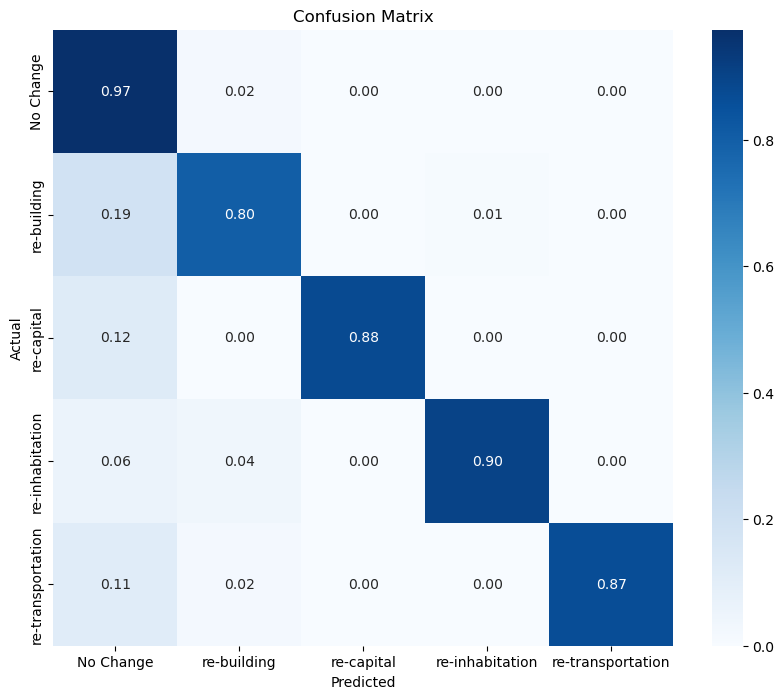

In [28]:
# Classification Report
classes = val_dataset.dataset.label_encoder.classes_
print(classification_report(val_labels, val_preds, target_names=classes, digits=4))

# Confusion Matrix
conf_matrix = confusion_matrix(val_labels, val_preds, normalize='true')
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt=".2f", cmap="Blues", xticklabels=classes, yticklabels=classes)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

### 8.2 Training Progress Visualization

Plot training and validation metrics over epochs:
- Per-class accuracy curves for training and validation
- Overall accuracy trends
- Helps identify overfitting, convergence, and class-specific performance patterns


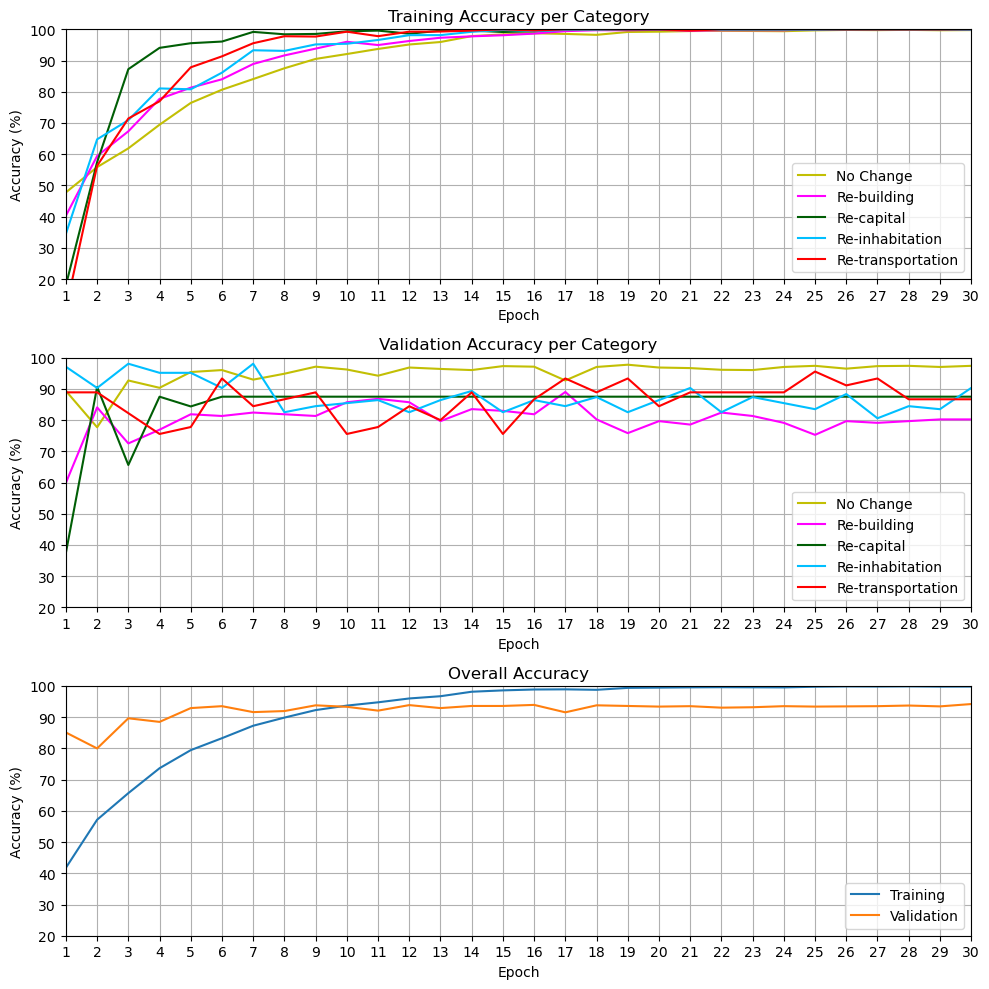

In [29]:
# visualize accuracy graphs.

import matplotlib.pyplot as plt

# Define class labels
classes = ['No Change', 'Re-building', 'Re-capital', 'Re-inhabitation', 'Re-transportation']

color_map = {
    'No Change': "#c2bf04",         # gold
    'Re-building': "#ff00ff",       # darkorange
    'Re-capital': "#005E05",        # magneta
    'Re-inhabitation': '#00bfff',   # red
    'Re-transportation': '#ff0000'  # deepskyblue
}

# Epochs
epochs = list(range(1, len(train_acc_per_class) + 1))

# Helper to convert list of lists to class-wise dict
def transpose_to_class_dict(data):
    return {cls: [epoch_data[i] for epoch_data in data] for i, cls in enumerate(classes)}

# Convert input lists to class-wise dicts
train_acc_class = transpose_to_class_dict(train_acc_per_class)
val_acc_class = transpose_to_class_dict(val_acc_per_class)
train_loss_class = transpose_to_class_dict(train_loss_per_class)
val_loss_class = transpose_to_class_dict(val_loss_per_class)

# Plotting
fig, axs = plt.subplots(3, 1, figsize=(10, 10))

# Training Accuracy per Class
for cls in classes:
    axs[0].plot(epochs, train_acc_class[cls], label=cls, color=color_map[cls])
axs[0].set_title('Training Accuracy per Category')
axs[0].set_xlabel('Epoch')
axs[0].set_ylabel('Accuracy (%)')
axs[0].set_xticks(epochs)
axs[0].set_xlim(1,30)
axs[0].set_ylim(20,100)
# axs[0].set_yticks(list(range(0,101,10))) 
axs[0].legend(loc='lower right')
axs[0].legend()

# Validation Accuracy per Class
for cls in classes:
    axs[1].plot(epochs, val_acc_class[cls], label=cls, color=color_map[cls])
axs[1].set_title('Validation Accuracy per Category')
axs[1].set_xlabel('Epoch')
axs[1].set_ylabel('Accuracy (%)')
axs[1].set_xticks(epochs)
axs[1].set_xlim(1,30)
axs[1].set_ylim(20,100)
axs[1].legend()

# Overall Accuracy
axs[2].plot(epochs, overall_train_acc, label='Training')
axs[2].plot(epochs, overall_val_acc, label='Validation')
axs[2].set_title('Overall Accuracy')
axs[2].set_xlabel('Epoch')
axs[2].set_ylabel('Accuracy (%)')
axs[2].set_xticks(epochs)
axs[2].set_xlim(1,30)
axs[2].set_ylim(20,100)
axs[2].legend()

# turn the grid on for every subplot
for ax in axs.ravel():
    ax.grid(True)
    ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

### 8.3 Prediction Visualization

Load the trained model and visualize sample predictions:
- Display correct and incorrect predictions for each class
- Show before/after image pairs with predicted labels and confidence scores
- Include metadata (census block, location, dates) for context


2026-04-27 23:34:16,486 - INFO - Loading pretrained weights from Hugging Face hub (timm/vit_base_patch16_224.augreg2_in21k_ft_in1k)
2026-04-27 23:34:16,664 - INFO - [timm/vit_base_patch16_224.augreg2_in21k_ft_in1k] Safe alternative available for 'pytorch_model.bin' (as 'model.safetensors'). Loading weights using safetensors.


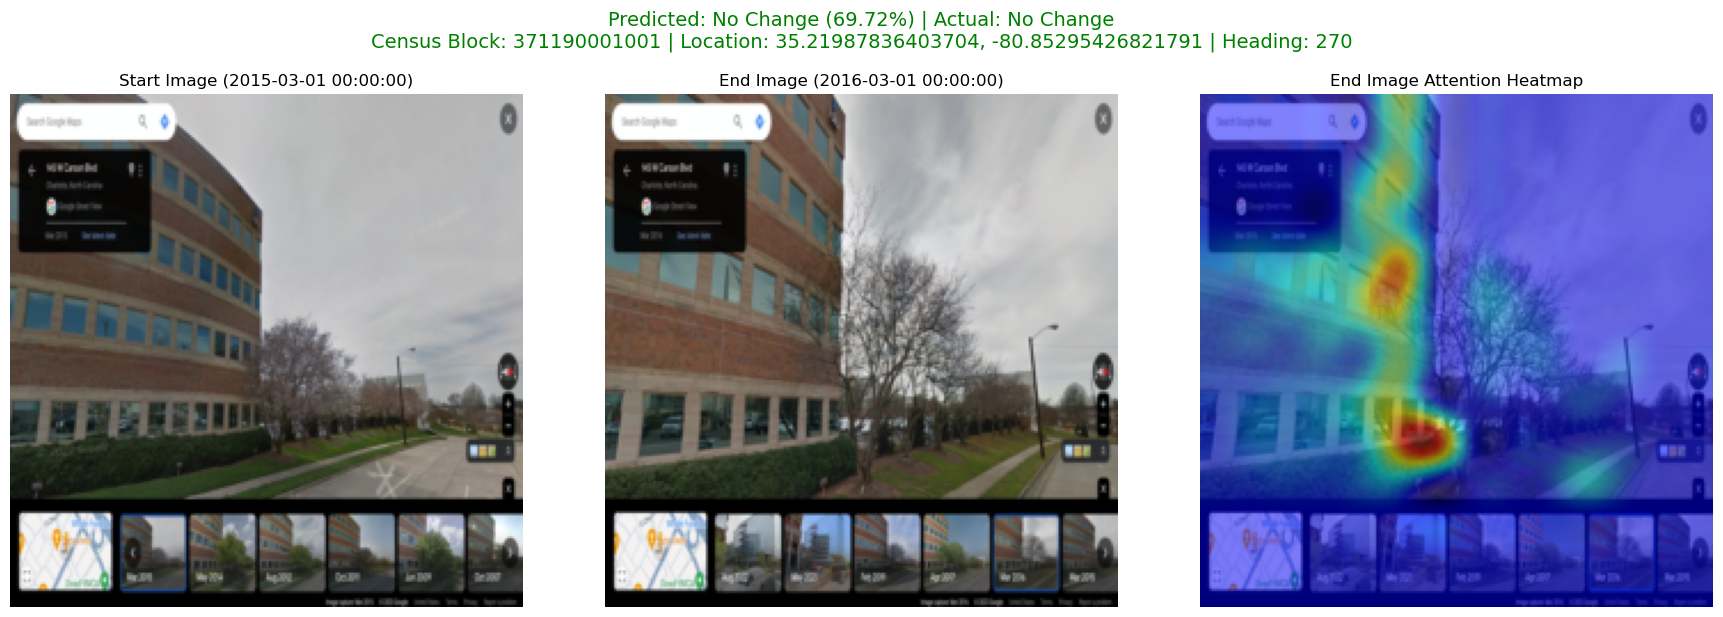

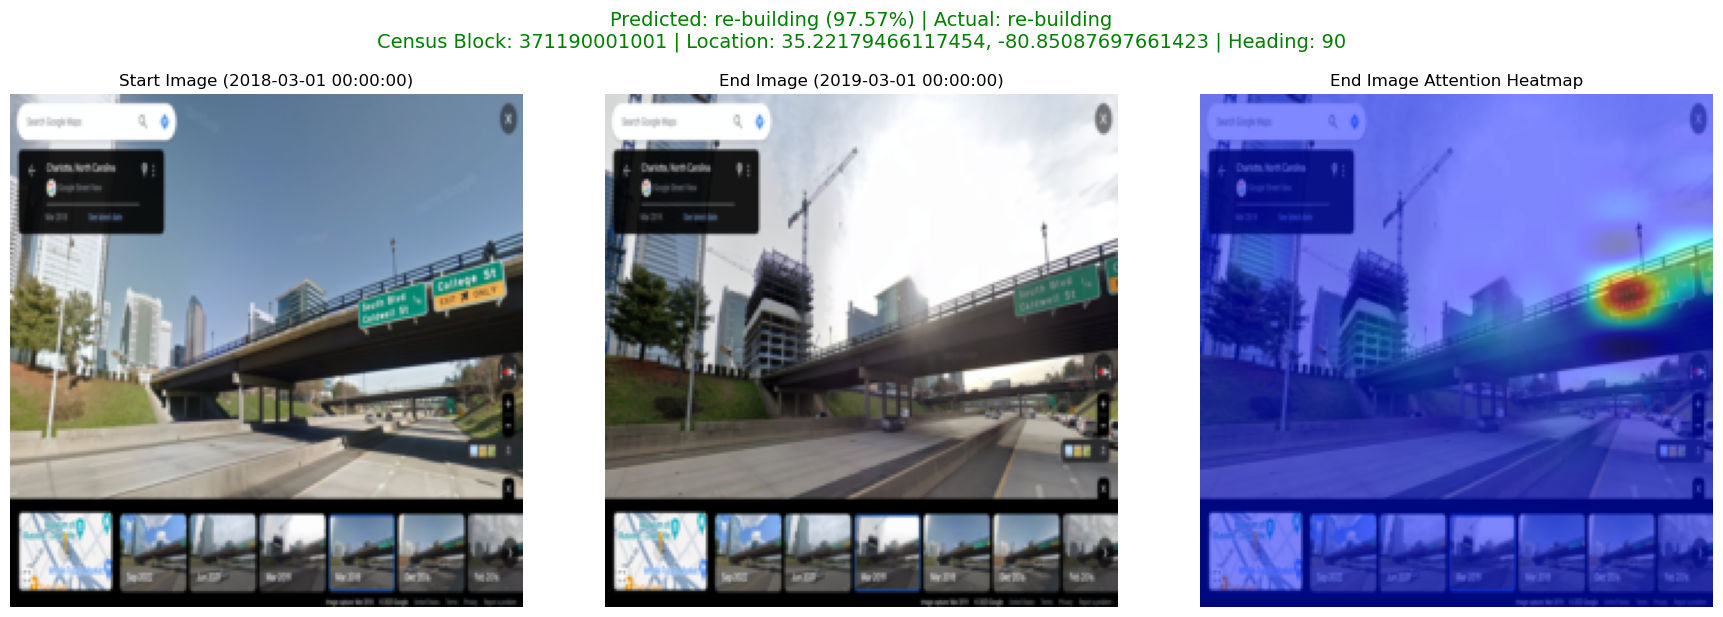

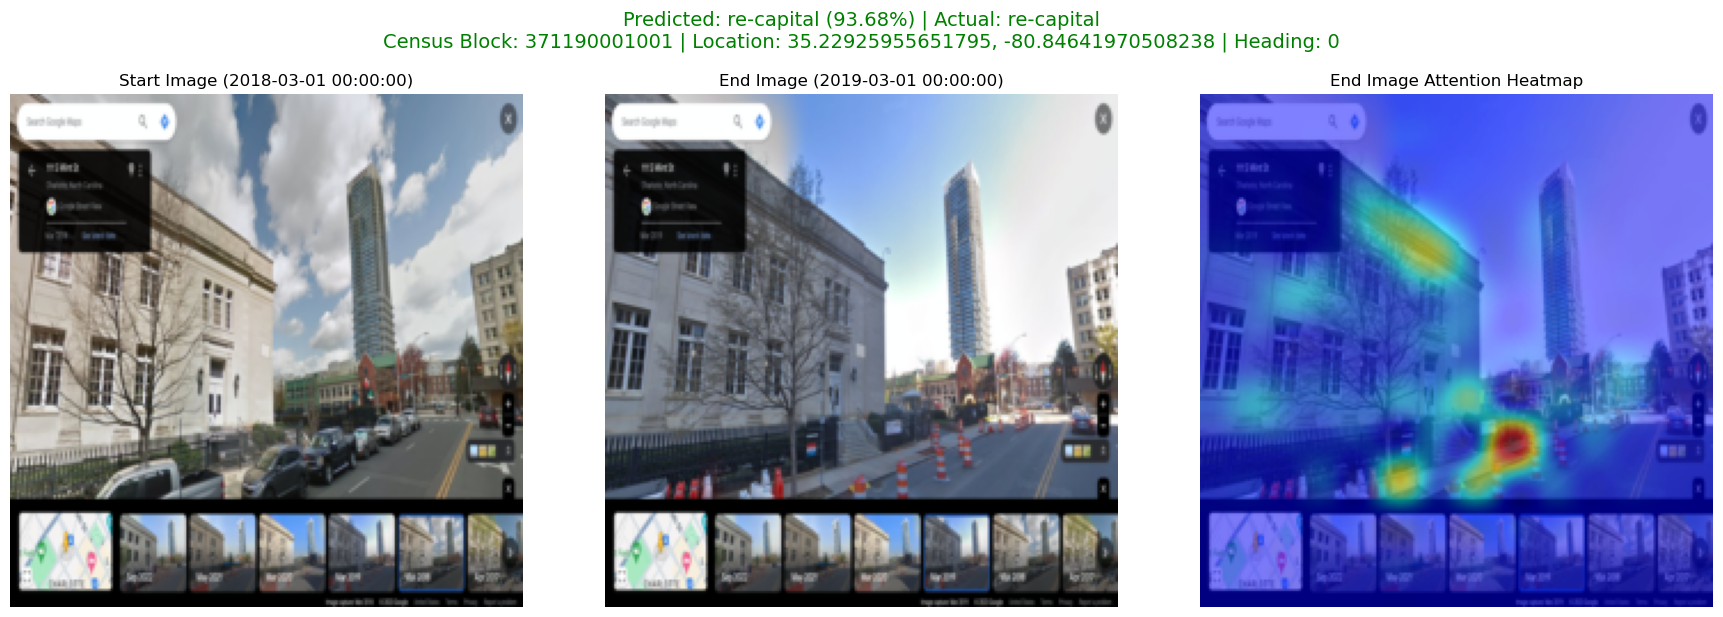

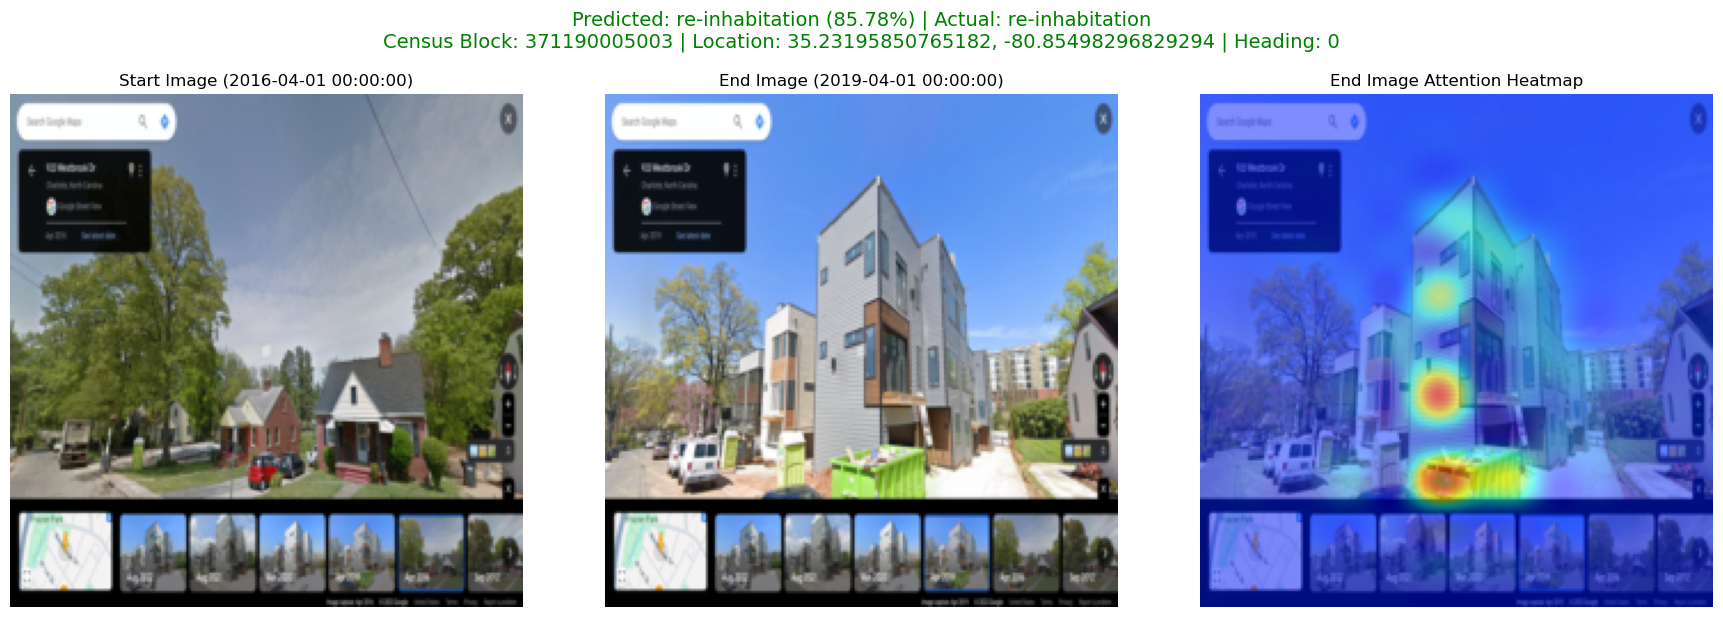

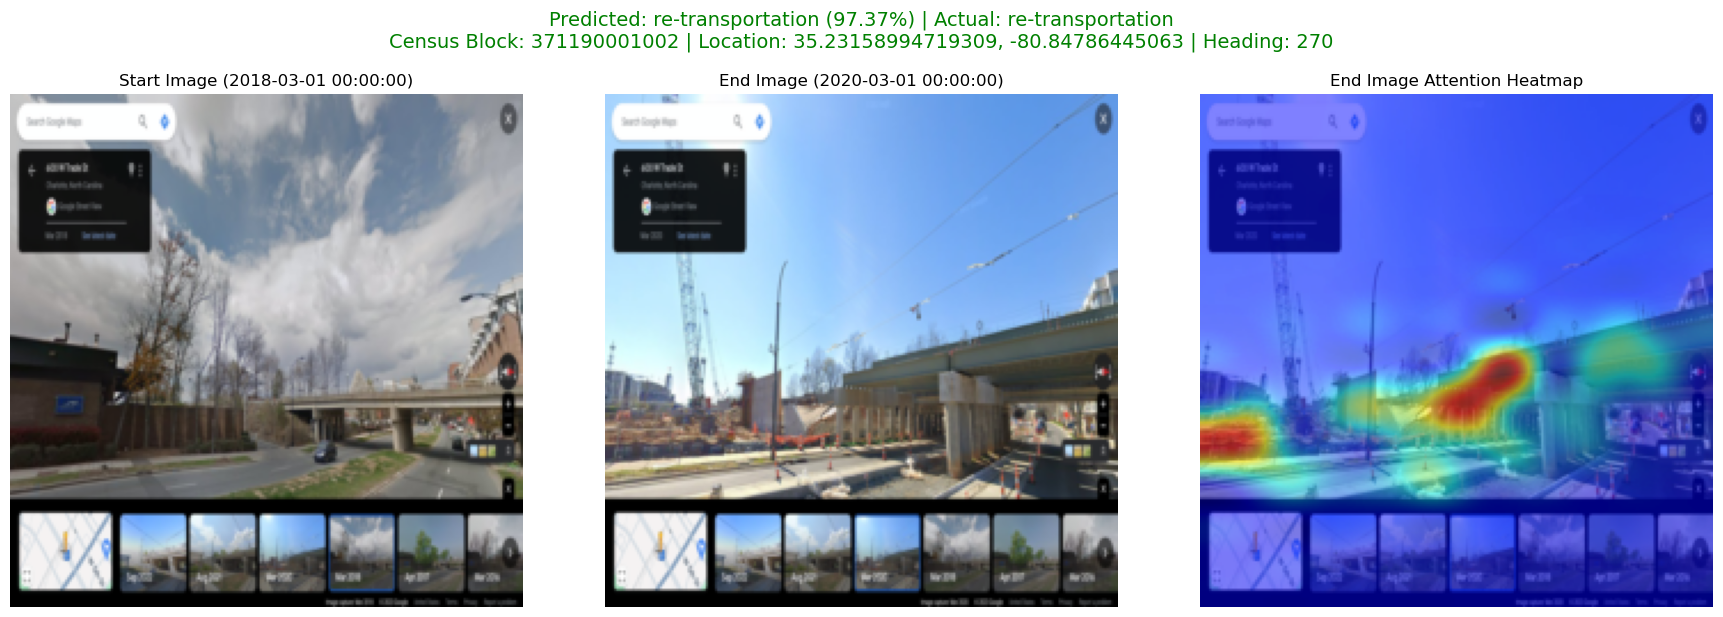

In [30]:
# visualize predictions of the model with attention maps

def get_attention_map(model, img_tensor, device):
    attentions = []
    def hook_fn(module, input, output):
        # Capture the attention weights
        attentions.append(output)
    
    # Access the last block's attention module
    attn_module = model.vit.blocks[-1].attn
    
    # TEMPORARILY disable fused attention if it exists to allow hooking into intermediate layers
    was_fused = getattr(attn_module, 'fused_attn', False)
    if hasattr(attn_module, 'fused_attn'):
        attn_module.fused_attn = False

    # Register hook on attn_drop (which receives the softmax output in standard timm ViT)
    handle = None
    if hasattr(attn_module, 'attn_drop'):
        handle = attn_module.attn_drop.register_forward_hook(hook_fn)
    else:
        # Fallback for different timm versions
        handle = attn_module.register_forward_hook(hook_fn)

    input_tensor = img_tensor.unsqueeze(0).to(device)
    model.eval()
    with torch.no_grad():
        _ = model.vit(input_tensor)
    
    if handle: handle.remove()
    # Restore fused_attn state
    if hasattr(attn_module, 'fused_attn'):
        attn_module.fused_attn = was_fused
    
    if not attentions:
        return np.zeros((14, 14)) # Return empty if failed
    
    attn = attentions[0]
    if isinstance(attn, tuple): attn = attn[0]
    
    # Average across heads (dim 1) and take CLS token (index 0) attention to all patches (index 1:)
    # attn shape: (batch, heads, tokens, tokens)
    cls_attn = attn[0, :, 0, 1:].mean(dim=0)
    
    # Reshape to (14, 14) for 224x224 input with patch_size 16
    return cls_attn.reshape(14, 14).cpu().numpy()

# visualize predictions of the model
if device.type == 'cuda':    
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=num_workers, pin_memory=True)
else:
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

model = ViTWithSocioEconomic(2, NUM_CLASSES).to(device)
CHECKPOINT_PATH = "Model_Checkpoints/MURD-ViT_weights.pth"
checkpoint = torch.load(CHECKPOINT_PATH, weights_only=False) if device.type == "cuda" else torch.load(CHECKPOINT_PATH, weights_only=False, map_location=device) # Target CPU in this case.
model.load_state_dict(checkpoint['model_state_dict'])

# Re-run validation to get all outputs
model.eval()
all_preds = []
all_labels = []
all_probs = []
all_paths = []

with torch.no_grad():
    for batch_idx, batch in enumerate(val_loader):
        start_imgs, end_imgs, socio_econ, labels = batch
        start_imgs, end_imgs = start_imgs.to(device), end_imgs.to(device)
        socio_econ, labels = socio_econ.to(device), labels.to(device)
        
        outputs = model(start_imgs, end_imgs, socio_econ)
        probs = torch.softmax(outputs, dim=1)
        top_probs, preds = torch.max(probs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(top_probs.cpu().numpy())

        # Save for visualization
        for i in range(len(labels)):
            idx = batch_idx * BATCH_SIZE + i
            metadata = val_dataset.dataset.data.iloc[val_dataset.indices[idx]]
            all_paths.append({
                'start_img': start_imgs[i].cpu(),
                'end_img': end_imgs[i].cpu(),
                'label': labels[i].item(),
                'pred': preds[i].item(),
                'confidence': top_probs[i].item(),
                'census_block': metadata['ID'],
                'lat': metadata['Latitude'],
                'lon': metadata['Longitude'],
                'heading': metadata['Heading'],
                'start_date': metadata['Start'],
                'end_date': metadata['End']
            })

# Organize samples by class
class_samples = {i: {'correct': [], 'incorrect': []} for i in range(NUM_CLASSES)}

for info in all_paths:
    cls = info['label']
    if info['pred'] == info['label']:
        if len(class_samples[cls]['correct']) < 1:
            class_samples[cls]['correct'].append(info)
    else:
        if len(class_samples[cls]['incorrect']) < 1:
            class_samples[cls]['incorrect'].append(info)

# Define label map
label_map = dict(enumerate(val_dataset.dataset.label_encoder.classes_))

# Plotting function (1x3 High-Res layout)
def plot_sample_with_attention_3column(info, model, device, label_map=None):
    if label_map is None:
        import __main__
        label_map = getattr(__main__, 'label_map', {})
    
    # Get attention map for the end image
    end_attn = get_attention_map(model, info['end_img'], device)
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    # 1. Start Image
    start_img = info['start_img'].permute(1, 2, 0).numpy()
    start_img = start_img * [0.229, 0.224, 0.225] + [0.485, 0.456, 0.406]  # Unnormalize
    start_img = np.clip(start_img, 0, 1)
    axes[0].imshow(start_img)
    axes[0].set_title(f"Start Image ({info['start_date']})", fontsize=12)
    axes[0].axis('off')
    
    # 2. End Image
    end_img = info['end_img'].permute(1, 2, 0).numpy()
    end_img = end_img * [0.229, 0.224, 0.225] + [0.485, 0.456, 0.406]  # Unnormalize
    end_img = np.clip(end_img, 0, 1)
    axes[1].imshow(end_img)
    axes[1].set_title(f"End Image ({info['end_date']})", fontsize=12)
    axes[1].axis('off')
    
    # 3. Attention Heatmap on End Image
    # Use LANCZOS4 for higher resolution smoothing
    heatmap = cv2.resize(end_attn, (224, 224), interpolation=cv2.INTER_LANCZOS4)
    if heatmap.max() > heatmap.min():
        heatmap = (heatmap - heatmap.min()) / (heatmap.max() - heatmap.min() + 1e-8)
    
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
    
    # Superimpose heatmap on End image
    overlayed = cv2.addWeighted(np.uint8(255 * end_img), 0.5, heatmap, 0.5, 0)
    axes[2].imshow(overlayed)
    axes[2].set_title("End Image Attention Heatmap", fontsize=12)
    axes[2].axis('off')

    pred_label = label_map.get(info['pred'], f'Class {info["pred"]}')
    actual_label = label_map.get(info['label'], 'Unknown')
    
    plt.suptitle(
        f"Predicted: {pred_label} ({info['confidence']*100:.2f}%) | Actual: {actual_label}\nCensus Block: {info['census_block']} | Location: {info['lat']}, {info['lon']} | Heading: {info['heading']}",
        color='green' if info['pred'] == info['label'] else 'red',
        fontsize=14,
        y=1.02
    )
    plt.tight_layout()
    plt.show()

# Display 2 per class (correct + incorrect)
for cls in range(NUM_CLASSES):
    if class_samples[cls]['correct']:
        plot_sample_with_attention_3column(class_samples[cls]['correct'][0], model, device, label_map=label_map)
    if class_samples[cls]['incorrect']:
        plot_sample_with_attention_3column(class_samples[cls]['incorrect'][0], model, device, label_map=label_map)


### Take a look at comprehensive sample predictions of each category.

<img alt= "Model Prediction" src="data/figures_low/prediction_viz_with_attention.png" width="1300" height="1600" />


### 8.4 Export Predictions to Excel

Run inference on the validation dataset and save predictions to an Excel file. This includes:
- Original data columns
- Model predictions (encoded and label format)
- Enables further analysis and accuracy calculation by census block groups


In [31]:
# Store model's prediction for full dataset to an excel file from which accuracy for each category across census blocks group can be calculated.

# Data Loading
# Dataset and DataLoader
# excel_File = "labels.xlsx"
# image_dir = "Streetview_data"
# BATCH_SIZE = 256
# NUM_CLASSES = 5
# Set random seed for reproducibility
np.random.seed(42)
torch.manual_seed(42)

val_transform = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Load entire dataset first with val_transform (no augmentation, just resizing and normalization)
full_dataset = UrbanRetrofittingDataset(excel_File, image_dir, val_transform)

# Get only validation subset using original val_indices
val_subset = Subset(full_dataset, val_indices)

if device.type == 'cuda':
    data_loader = DataLoader(val_subset, batch_size=BATCH_SIZE, shuffle=False, num_workers=num_workers, pin_memory=True)
else:
    data_loader = DataLoader(val_subset, batch_size=BATCH_SIZE, shuffle=False)

model = ViTWithSocioEconomic(2, NUM_CLASSES).to(device)
CHECKPOINT_PATH = "Model_Checkpoints/MURD-ViT_weights.pth"
checkpoint = torch.load(CHECKPOINT_PATH, weights_only=False) if device.type == "cuda" else torch.load(CHECKPOINT_PATH, weights_only=False, map_location=device) # Target CPU in this case.
model.load_state_dict(checkpoint['model_state_dict'])

# Set model to eval mode
model.eval()

# Collect predictions and true labels
all_preds = []
all_true_labels = []

with torch.no_grad():
    for start_imgs, end_imgs, socio_econ, labels in data_loader:
        start_imgs = start_imgs.to(device)
        end_imgs = end_imgs.to(device)
        socio_econ = socio_econ.to(device)

        outputs = model(start_imgs, end_imgs, socio_econ)
        _, predicted = torch.max(outputs, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_true_labels.extend(labels.cpu().numpy())

# Reload original Excel (to retain all original columns)
df = pd.read_excel(excel_File, dtype={"Latitude": str, "Longitude": str})
df = df.astype({"Latitude": np.longdouble, "Longitude": np.longdouble})
# filter validation rows only.
df = df.iloc[val_indices]

# Fit label encoder again to get label mappings
label_encoder = LabelEncoder()
df['Change_Encoded'] = label_encoder.fit_transform(df['Change'])

# Add predictions
df['Prediction'] = all_preds
df['Prediction_Label'] = label_encoder.inverse_transform(df['Prediction'].astype(int))

# Save to new Excel
output_excel = "data/val_dataset_predictions_for_mapping.xlsx"
df.to_excel(output_excel, index=False)

print(f"✅ Predictions for validation dataset saved to: {output_excel}")


2026-04-27 23:35:17,685 - INFO - Loading pretrained weights from Hugging Face hub (timm/vit_base_patch16_224.augreg2_in21k_ft_in1k)
2026-04-27 23:35:17,812 - INFO - [timm/vit_base_patch16_224.augreg2_in21k_ft_in1k] Safe alternative available for 'pytorch_model.bin' (as 'model.safetensors'). Loading weights using safetensors.


✅ Predictions for validation dataset saved to: data/val_dataset_predictions_for_mapping.xlsx


### 8.5 Accuracy Calculation per Census Block Group (Continues with Data exported from above.)

Calculate model accuracy metrics for each census block group:
- Overall accuracy per block group
- Per-class accuracy for each category
- Merge results with shapefile for geographic visualization
- Export as shapefile for GIS analysis and mapping


In [32]:
# Now, calculate accuracy for each category across census blocks group and merge with shapefile for model accuracy visualization.

import pandas as pd
import geopandas as gpd
import numpy as np

# Load files
excel_file = "data/val_dataset_predictions_for_mapping.xlsx"
shp_file = "data/Shapefile/mecklengburg_county_census_block_group_2013.shp"
output_shp = "data/Shapefile/accuracy_per_census_block_group.shp"

# Load Excel data
df = pd.read_excel(excel_file)

# Ensure ID is string for merge
df['ID'] = df['ID'].astype(str)

# List all unique true change categories in the dataset
all_categories = df['Change'].dropna().unique()

# Function to compute accuracy metrics per Census Block Group
def compute_accuracy(group):
    total = len(group)
    correct = (group['Change'] == group['Prediction_Label']).sum()
    overall_acc = round((correct / total) * 100, 2) if total else np.nan
    result = {'overall_accuracy': overall_acc}

    # Compute accuracy per category
    for category in all_categories:
        cat_group = group[group['Change'] == category]
        cat_total = len(cat_group)
        if cat_total:
            correct_cat = (cat_group['Change'] == cat_group['Prediction_Label']).sum()
            cat_acc = round((correct_cat / cat_total) * 100, 2)
        else:
            cat_acc = np.nan
        result[f'acc_{category}'] = cat_acc

    return pd.Series(result)

# Apply the accuracy function per Census Block Group
accuracy_by_id = df.groupby('ID').apply(compute_accuracy).reset_index()

# Load the shapefile
gdf = gpd.read_file(shp_file)

# Ensure GEOID is string for merging
gdf['GEOID'] = gdf['GEOID'].astype(str)

# Merge shapefile with accuracy data
merged_gdf = gdf.merge(accuracy_by_id, how='left', left_on='GEOID', right_on='ID')

# Identify accuracy columns (those starting with 'acc_' or 'overall_accuracy')
accuracy_cols = [col for col in merged_gdf.columns if col.startswith('acc_') or col == 'overall_accuracy']
print(accuracy_cols)
# Replace NaN with -9999 in only those columns
merged_gdf[accuracy_cols] = merged_gdf[accuracy_cols].fillna(-9999)

# Export the merged shapefile.
merged_gdf.to_file(output_shp)

/tmp/ipykernel_536/1964803276.py:60: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  merged_gdf.to_file(output_shp)
/home/jovyan/.local/geoai/lib/python3.11/site-packages/pyogrio/raw.py:733: RuntimeWarning: Normalized/laundered field name: 'overall_accuracy' to 'overall_ac'
  ogr_write(
/home/jovyan/.local/geoai/lib/python3.11/site-packages/pyogrio/raw.py:733: RuntimeWarning: Normalized/laundered field name: 'acc_No Change' to 'acc_No Cha'
  ogr_write(
/home/jovyan/.local/geoai/lib/python3.11/site-packages/pyogrio/raw.py:733: RuntimeWarning: Normalized/laundered field name: 'acc_re-building' to 'acc_re-bui'
  ogr_write(
/home/jovyan/.local/geoai/lib/python3.11/site-packages/pyogrio/raw.py:733: RuntimeWarning: Normalized/laundered field name: 'acc_re-capital' to 'acc_re-cap'
  ogr_write(
/home/jovyan/.local/geoai/lib/python3.11/site-packages/pyogrio/raw.py:733: RuntimeWarning: Normalized/laundered field name: 'acc_re-transportation' 

['overall_accuracy', 'acc_No Change', 'acc_re-building', 'acc_re-capital', 'acc_re-transportation', 'acc_re-inhabitation']


### Let's take a look at above exported shapefile. Here, an image is directly loaded because we don't get that many visualization flexibility as needed in python. But, this data can be easily visualized using geopandas and matplotlib in python.

<img alt="Model Prediction Accuracy" src="data/figures_low/prediction_accuracy.png" width="1100" height="750" />


## 9. <a id="conclusion">Conclusion</a>

**MURD-ViT** introduces the first multimodal framework specifically engineered to detect micro-scale urban retrofitting. By fusing temporal **Street View Imagery (SVI)** with **demographic data**, the model transcends the limitations of traditional satellite sensing.

### Key Contributions
* **Comprehensive Detection:** Successfully identifies *where*, *when*, and *what* type of retrofitting occurred across five distinct categories.
* **Scalability & Generalizability:** Trained on a diverse range of urban scenes, the model demonstrates robust performance, suggesting high potential for deployment in other rapidly evolving global cities.
* **Policy & Planning Tool:** Provides urban planners with a longitudinal view of city transformation, helping monitor renewal projects and evaluate impacts on vulnerable populations.
* **Resilience Metrics:** Offers environmental experts quantitative insights into how retrofitting contributes to urban sustainability and climate resilience.

## 10.<a id="limitations"> Limitations and Future Direction</a>

While MURD-ViT marks a significant milestone, several avenues for refinement remain:

### Current Challenges
* **Spatial Mismatch:** Demographic data is currently captured at the Census Block Group level, which is coarser than the pinpoint precision of Street View coordinates.
* **Environmental Noise:** Model accuracy can be affected by seasonal changes, varying lighting conditions, and visually similar architectural objects.
* **Geographic Scope:** Performance in significantly different architectural or demographic contexts (outside the US) remains untested.

### The Path Forward
1.  **Foundational Model Development:** Expanding the training set to include global datasets across multiple decades to create a "Universal Urban Retrofitting Model."
2.  **Higher Resolution Indicators:** Integrating parcel-level socioeconomic data to match the granularity of visual inputs.
3.  **Domain Adaptation:** Utilizing transfer learning to ensure the model maintains accuracy when migrating to cities with unique aesthetic or structural styles.
4.  **Scope Expansion:** Broadening the detection capabilities to include a wider array of urban transformations and infrastructure health metrics.

## 11.<a id="direct-use"> User specifically interested in using data directly rather than from excel file annotations</a>

1. Import all dependencies after done with [Installation and Setup](#installation)
2. Load [Model Architecture](#architecture)
3. Run the following cell.

2026-04-27 23:35:49,373 - INFO - Loading pretrained weights from Hugging Face hub (timm/vit_base_patch16_224.augreg2_in21k_ft_in1k)
2026-04-27 23:35:49,434 - INFO - [timm/vit_base_patch16_224.augreg2_in21k_ft_in1k] Safe alternative available for 'pytorch_model.bin' (as 'model.safetensors'). Loading weights using safetensors.


✅ Model weights loaded. Ready for inference.


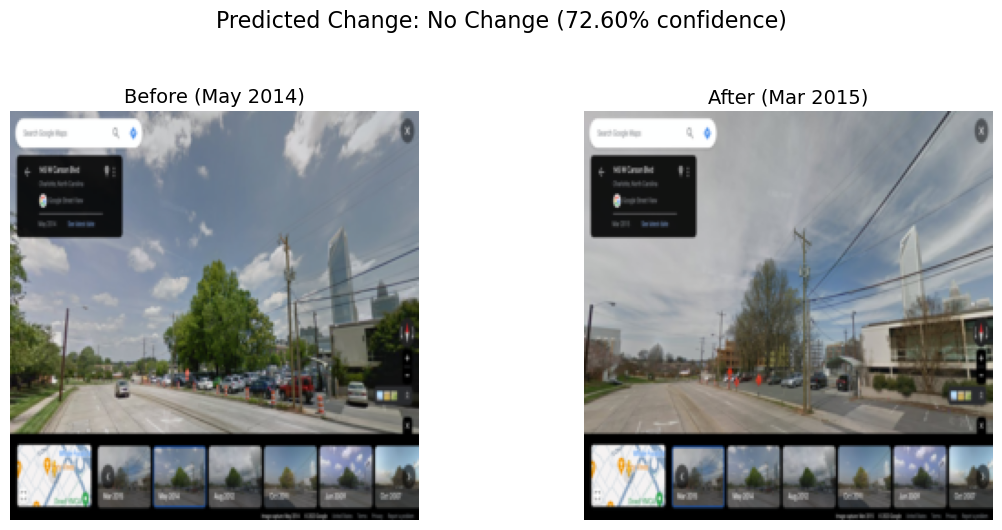

In [33]:
# INFERENCE FOR CUSTOM IMAGE PAIRS (WITHOUT EXCEL)
# This cell allows new users to directly load two images, 
# run the MURD-ViT model, and visualize the predicted urban change.

import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import os

# 1. Define a Simple Dataset for Direct Image Loading
class CustomPairDataset(Dataset):
    def __init__(self, image_pairs, socio_data_list, transform=None):
        """
        Args:
            image_pairs (list of tuples): List of (path_to_before_img, path_to_after_img).
            socio_data_list (list of lists): List of [PopDen_Diff, PopDen_Diff_Percentage].
            transform (callable, optional): Transforms to apply to images.
        """
        self.image_pairs = image_pairs
        self.socio_data = socio_data_list
        self.transform = transform

    def __len__(self):
        return len(self.image_pairs)

    def __getitem__(self, idx):
        path_before, path_after = self.image_pairs[idx]
        img_before = Image.open(path_before).convert('RGB')
        img_after = Image.open(path_after).convert('RGB')
        
        if self.transform:
            img_before = self.transform(img_before)
            img_after = self.transform(img_after)
            
        socio_tensor = torch.tensor(self.socio_data[idx], dtype=torch.float32)
        return img_before, img_after, socio_tensor, path_before, path_after

# 2. Setup Paths for Your Own Images
# Replace these paths with the location of your "before" and "after" images.
# For demonstration, we use a pair from the Sample_data folder.
before_img_path = "./data/Sample_data/Streetview_data/371190001001/35.21987836403704_-80.85295426821791_0/May 2014.png"
after_img_path = "./data/Sample_data/Streetview_data/371190001001/35.21987836403704_-80.85295426821791_0/Mar 2015.png"

# Provide socio-economic context [Population Density Change, Change Percentage].
# If unknown, you can use [0.0, 0.0] as a baseline.
custom_socio_economic = [195.6, 11.8]

# 3. Initialize Model and Load Weights
# Ensure 'device' and 'ViTWithSocioEconomic' are defined in earlier cells.
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = ViTWithSocioEconomic(num_numeric_features=2, num_classes=5).to(device)
weights_path = "./Model_Checkpoints/MURD-ViT_weights.pth"

if os.path.exists(weights_path):
    checkpoint = torch.load(weights_path, map_location=device, weights_only=False)
    # Handle both full checkpoints and state-only dicts
    state_dict = checkpoint['model_state_dict'] if 'model_state_dict' in checkpoint else checkpoint
    model.load_state_dict(state_dict)
    model.eval()
    print("✅ Model weights loaded. Ready for inference.")
else:
    print(f"❌ Weights file not found at {weights_path}. Please download it first.")

# 4. Prepare Data and Run Prediction
inference_transform = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Create Dataset and Loader for the custom pair
custom_ds = CustomPairDataset([(before_img_path, after_img_path)], [custom_socio_economic], transform=inference_transform)
custom_loader = DataLoader(custom_ds, batch_size=1)

# Prediction Categories (Standard MURD-ViT classes)
class_names = ['No Change', 're-building', 're-capital', 're-inhabitation', 're-transportation']

for img_before, img_after, socio, p_before, p_after in custom_loader:
    with torch.no_grad():
        output = model(img_before.to(device), img_after.to(device), socio.to(device))
        probs = torch.softmax(output, dim=1)
        pred_idx = torch.argmax(probs, dim=1).item()
        confidence = probs[0, pred_idx].item() * 100

    # Extract dates from filenames (e.g., "May 2014.png" -> "May 2014")
    date_before = os.path.basename(p_before[0]).replace(".png", "")
    date_after = os.path.basename(p_after[0]).replace(".png", "")

    # 5. Visualization
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    titles = [f"Before ({date_before})", f"After ({date_after})"]
    
    for i, (img_tensor, title) in enumerate(zip([img_before[0], img_after[0]], titles)):
        # Unnormalize for visualization
        img = img_tensor.cpu().permute(1, 2, 0).numpy()
        img = img * [0.229, 0.224, 0.225] + [0.485, 0.456, 0.406]
        axes[i].imshow(np.clip(img, 0, 1))
        axes[i].set_title(title, fontsize=14)
        axes[i].axis('off')
    
    plt.suptitle(f"Predicted Change: {class_names[pred_idx]} ({confidence:.2f}% confidence)", fontsize=16, y=1.05)
    plt.tight_layout()
    plt.show()


## References

> Ma, Xinlin, Yan Song, Fangzheng Lyu, Yang Yang, Yuhua Wang, Xijing Li, and Shaopeng Zhong. 2025. “Revitalizing Cities: The 5R Framework Approach to Urban Retrofitting and Big Data Insights.” *Growth and Chang*e 56 (1). https://doi.org/10.1111/grow.70018.

Learn more at [GitHub Repo](https://github.com/GeoComputeLab/IGUIDE-Spatial-AI-Challenge)